In [6]:
from datascience import *
import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
def standard_units(arr):
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

def residuals(t, x, y):
    """Return an array of all the residuals"""
    predictions = fitted_values(t, x, y)
    return t.column(y) - predictions


In [8]:
# Ignore this code; it's graphics for demonstrating the regression model
def draw_and_compare(true_slope, true_int, sample_size):
    x = np.random.normal(50, 5, sample_size)
    xlims = np.array([np.min(x), np.max(x)])
    errors = np.random.normal(0, 6, sample_size)
    y = (true_slope * x + true_int) + errors
    sample = Table().with_columns('x', x, 'y', y)

    sample.scatter('x', 'y')
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title('True Line, and Points Created')

    sample.scatter('x', 'y')
    plt.title('What We Get to See')

    sample.scatter('x', 'y', fit_line=True)
    plt.title('Regression Line: Estimate of True Line')

    sample.scatter('x', 'y', fit_line=True)
    plt.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plt.title("Regression Line and True Line")



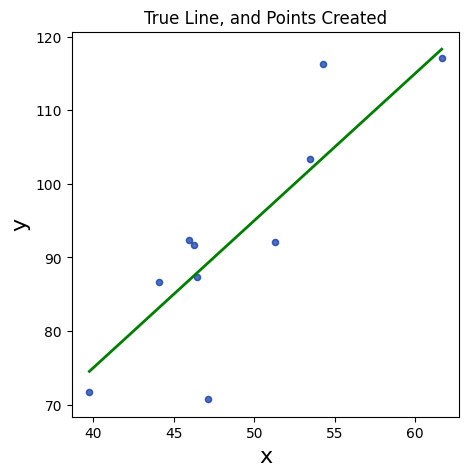

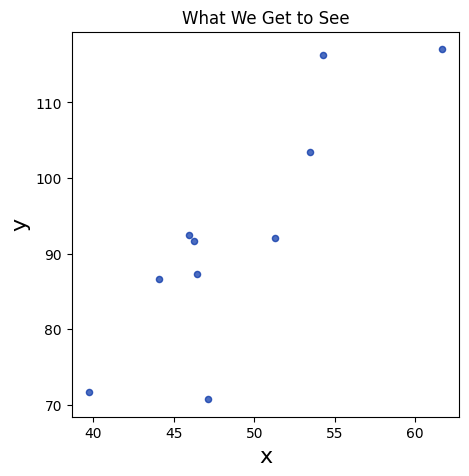

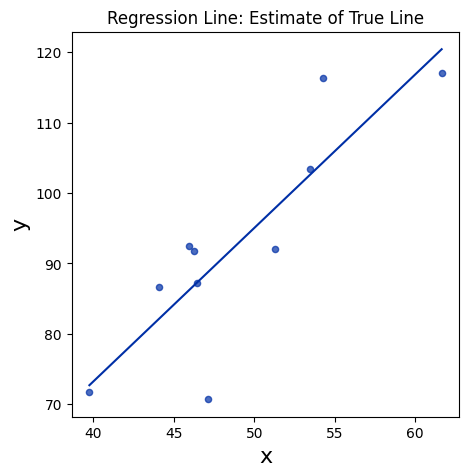

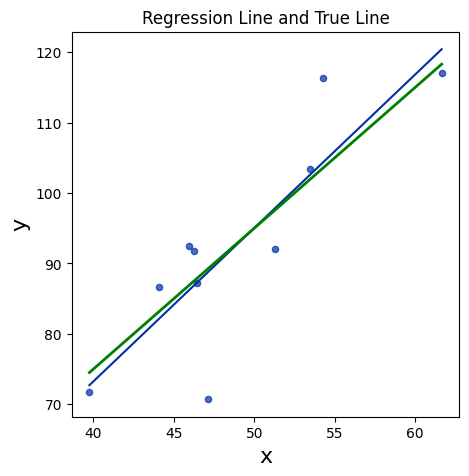

In [9]:
draw_and_compare(2, -5, 10)

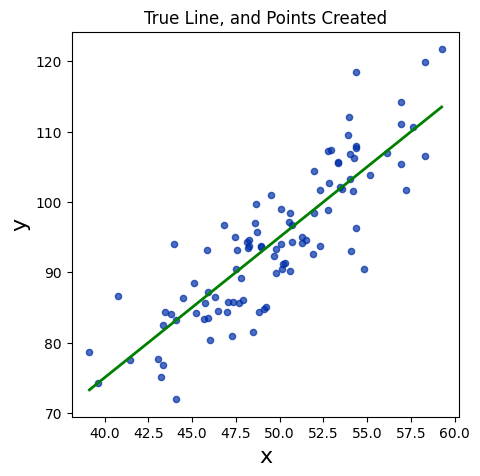

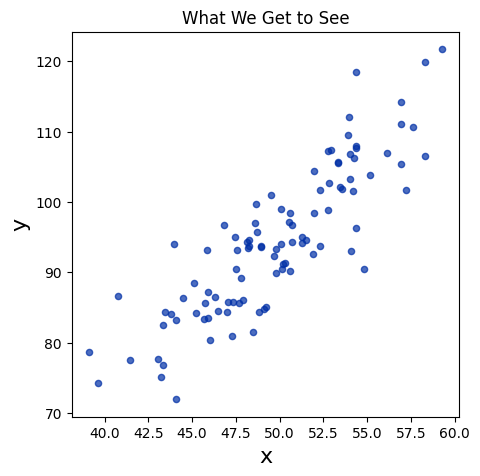

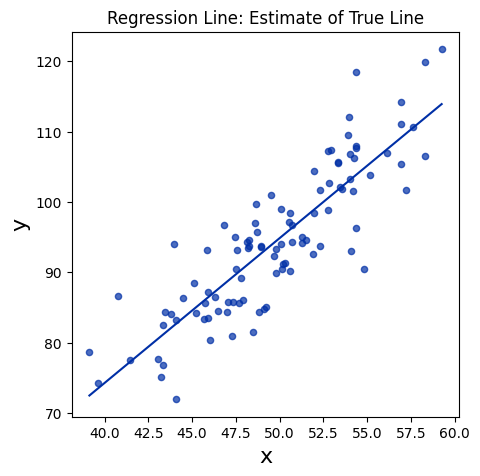

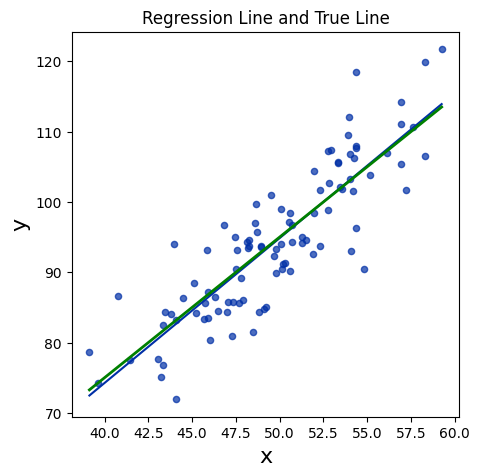

In [11]:
draw_and_compare(2, -5, 100)

In [12]:


births = Table.read_table('baby.csv')
births.show(3)



Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


In [13]:

# Preterm and postterm pregnancy cutoffs, according to the CDC
37 * 7, 42 * 7



(259, 294)

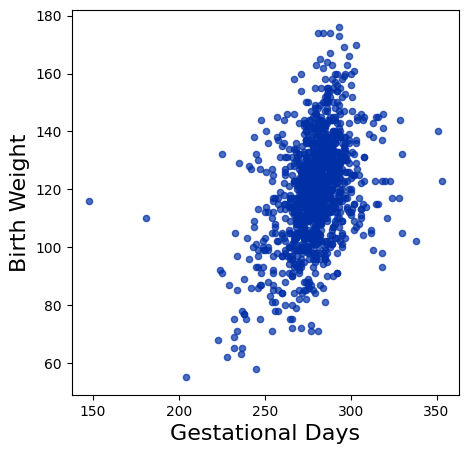

In [14]:
births.scatter('Gestational Days', 'Birth Weight')

In [15]:
births = births.where('Gestational Days', are.between(225, 325))

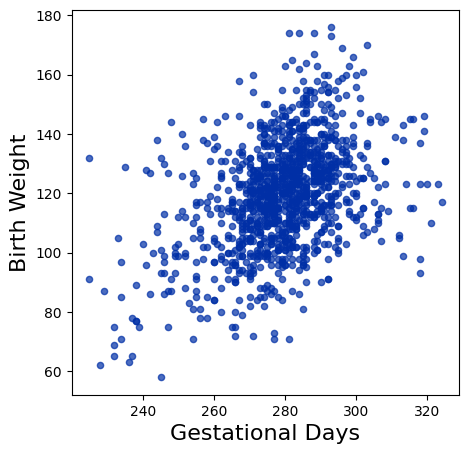

In [16]:
births.scatter('Gestational Days', 'Birth Weight')

In [17]:
correlation(births, 'Gestational Days', 'Birth Weight')

0.42295118452423991

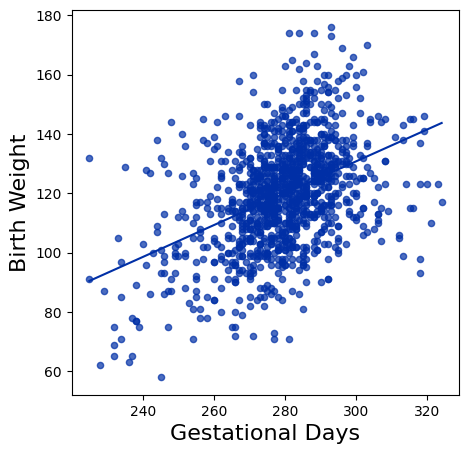

In [18]:
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)

In [19]:


def prediction_at(t, x, y, x_value):
    '''
    t - table
    x - label of x column
    y - label of y column
    x_value - the x value for which we want to predict y
    '''
    return slope(t, x, y) * x_value + intercept(t, x, y)



In [20]:


prediction_at_300 = prediction_at(births, 'Gestational Days', 'Birth Weight', 300)
prediction_at_300



130.80951674248769

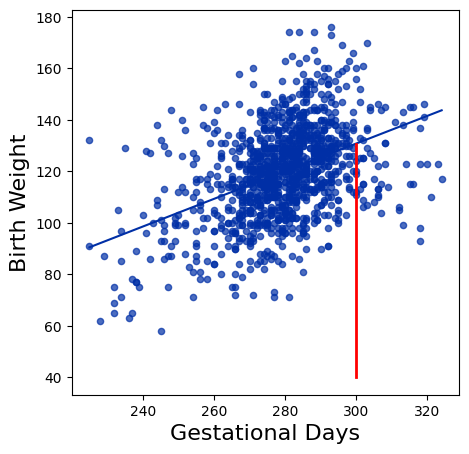

In [22]:


x = 300
births.scatter('Gestational Days', 'Birth Weight', fit_line=True)
plt.plot([x, x], [40, prediction_at_300], color='red', lw=2);

